# Lab 11 - Implementing Deep Learning Neural Network, CNN 1D

# Convolutional Neural Network (1D CNN)

Convolutional Neural Network sometimes can be used with one-dimensional sequences of data such as signal data, gyroscope or accelerometer data to do regression or classification. Time series forecasting is most suitable with sequential model such as LSTM. In this lab, you will learn how to build efficient and compact 1D CNN model with sequential data. 

1D convolution layer in Keras creates a convolution kernel that is convolved with the layer input over a single spatial (or temporal) dimension to produce a tensor of outputs.

1. Preparing tensor shape for 1D CNN
2. Implementing a 1D CNN for classification
3. Implementing a 1D CNN for regression

Instruction to complete lab exercises:

1. Open python notebook file under Lab folder
2. Read the problem statement in the exercise and expected output
3. Uncomment and remove the lines and fill in your answer
4. Run your code to produce expected output.

Noted: Data files are stored in dataset folder

# Preparing tensor shape for 1D CNN

Handling and preparing data such as time series for 1D CNN model needs some considerations. Tensor shape for 1D CNN model requires a three-dimensional input with (Samples, Time_steps, Features/channels). 

For example, one data sample may contain number of time steps for different channels. If we consider accelerometer it has x, y and z data. Assume a person is wearing it on his body and wrist. We collect data of 6 features which is 3 x 2 channels. Once we prepare the data, we need to consider time steps (duration). Assume 60 data points recorded with sampling rate of 20Hz (Duration – 60 * .05 =  3 seconds), 60 timesteps of 3 seconds is good window. We need to prepare the data in (Time_steps, Features) shape in this case (60, 6).

In the following example, dataset accelerometer_data.csv contains three accelerometer data acc_X, acc_Y and acc_Z. Last column is target activity column which records the activity from 1 - 7. Prepare time steps of 60 for each feature x, y and z. 

- Initial data shape: (162451, 3)
- Datashape with 60 time steps: (162451, 180)

Hence final 1D CNN input shape for the above data is (162451, 60, 3) with the input shape of (60 , 3)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Load the data from accelerometer_data.csv
# Display top 5

Note: Target Label column is activity and feature columns are 'accX','accY','accZ'

In [3]:
acdata = pd.read_csv("./dataset/accelerometer_data.csv")
print(acdata.head())

   No  accX  accY  accZ  activity
0   0  1502  2215  2215         1
1   1  1667  2072  2072         1
2   2  1611  1957  1957         1
3   3  1601  1939  1939         1
4   4  1643  1965  1965         1


# Function to generate windows of data based on timesteps

Function will take original datasets and two column names feature and target and timesteps to output new set of feature column with timesteps and target labels.

1. Parameter
- Original dataset
- Feature column name
- Target column name
- Number of timesteps

2. Output:
- nd-array data of X, y - (Samples, timesteps) , target label 

In [4]:
def genTimeStepData(ts, fcol, tcol, ntimesteps):   
    X = []
    y = []
    dcol = ts.loc[:, fcol]
    #print(dcol.shape)
    lcol = ts.loc[:, tcol]
    #print(lcol.shape)
    for i in range(ntimesteps, dcol.shape[0]):
        X.append(list(dcol.loc[i-ntimesteps:i-1]))
        y.append(lcol[i])
    X, y = np.array(X), np.array(y)
    return X, y

# Generate 60 timesteps each for a single column X

Output:

- (162441, 60)
- (162441,)

In [6]:
X_train, y_all = genTimeStepData(acdata, "accX", "activity", 60)

print(X_train.shape)
print(X_train[0])
print(y_all.shape)

(162441, 60)
[1502 1667 1611 1601 1643 1604 1640 1607 1546 1529 1637 1596 1590 1601
 1542 1598 1511 1555 1508 1580 1627 1592 1634 1638 1593 1542 1601 1613
 1644 1642 1605 1586 1577 1598 1561 1628 1694 1627 1598 1612 1630 1609
 1600 1608 1612 1605 1640 1610 1633 1573 1568 1576 1599 1620 1654 1637
 1603 1605 1620 1616]
(162441,)


# Exercise 1:

Continue using with datasets and function from the above example, generate 50 timesteps for all columns and produce as one single nd-array of (162441, 180). Target y label will be the same for all.

Expected output:

- (162441, 180)
- (162441,)

# Generate 60 timesteps for each column X, Y, Z
# Append or concatenate all 60x3 columns to X_all

Note: Output of target y will be same (162451,)

In [8]:

X_train, y_all =  genTimeStepData(acdata, "accX", "activity", 60)

Y_train, y_all =  genTimeStepData(acdata, "accY", "activity", 60)

Z_train, y_all =  genTimeStepData(acdata, "accY", "activity", 60)

X_all = np.concatenate((X_train, Y_train), axis = 1)
X_all =  np.concatenate((X_all, Z_train), axis = 1)

print(X_all.shape)
print(y_all.shape)

(162441, 180)
(162441,)


# Implementing a 1D CNN for classification

Classify different activity of a person who is wearing chest-mounted accelerometer. Dataset accelerometer_data.csv stored x, y and z data of the subject. Data monitor 7 activities of the subject. Every 4 seconds or 120 timesteps is worth to study. Prepare the data for 1D CNN with 120 timesteps for 3 features. Develop a 1D CNN model and train. 

1. Working at Computer
2. Walking up-down
3. Standing
4. Walking
5. Going up-down 
6. Walking and Talking with Someone
7. Talking while Standing

Expected Output:

Data set with timesteps:

- (129904, 120, 3)
- (32477, 120, 3)

Model Summary:

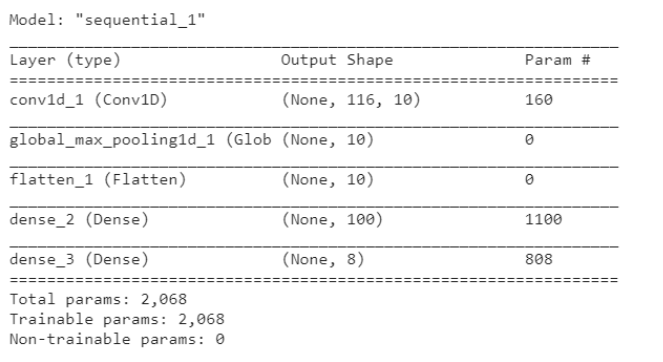


In [9]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [10]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Load the data from accelerometer_data.csv

In [11]:
acdata = pd.read_csv("./dataset/accelerometer_data.csv")

In [12]:
class_name = ["", "Working at Computer", "Walking up-down", "Standing", "Walking", "Going up-down", "Walking-Talking", "Talking-Standing"]

# Function to generate timesteps, feature format

Note: You can reuse the previous function

In [13]:
def generateTimeStepData(ts, fcol, tcol, ntimesteps):   
    X = []
    y = []
    dcol = ts.loc[:, fcol]
    #print(dcol.shape)
    lcol = ts.loc[:, tcol]
    #print(lcol.shape)
    for i in range(ntimesteps, dcol.shape[0]):
        X.append(list(dcol.loc[i-ntimesteps:i-1]))
        y.append(lcol[i])
    X, y = np.array(X), np.array(y)
    return X, y

# Generate 120 timesteps for each column X, Y, Z
# Append or concatenate all 120x3 columns to X_all

Note: Output of target y will be same (162451,)

In [14]:

X_train, y_all =  genTimeStepData(acdata, "accX", "activity", 120)
Y_train, y_all =  genTimeStepData(acdata, "accY", "activity", 120)
Z_train, y_all =  genTimeStepData(acdata, "accZ", "activity", 120)

X_all = np.concatenate((X_train, Y_train), axis = 1)
X_all =  np.concatenate((X_all, Z_train), axis = 1)

print(X_all.shape)
print(y_all.shape)

(162381, 360)
(162381,)


# Split the data into 80% train and 20% test dataset  

In [15]:
X_train, X_test, y_train, y_test =  train_test_split(X_all, y_all, test_size=0.2)

# Encode target label into y_train and y_test using onehot encoder.

Note: If you are unable to perform onehot encoder with your computer run this lab in the Google Colab environment

In [16]:

y_train = tf.keras.utils.to_categorical(y_train, num_classes = 8, dtype ="int32") 

y_test = tf.keras.utils.to_categorical(y_test, num_classes = 8, dtype ="int32")

print(X_train.shape)
print(y_train.shape)

(129904, 360)
(129904, 8)


# Reshape the data into the final tensor shape of (samples, timesteps, features)

Expected output:
- (129904, 120, 3)
- (32477, 120, 3)

In [19]:
X_train = X_train.reshape(X_train.shape[0], 120, 3).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 120, 3).astype('float32') 

print(X_train.shape)
print(X_test.shape)

(129904, 120, 3)
(32477, 120, 3)


# Create 1D CNN model with following layers configuration

Model summary

- Input layer with input shape of (120, 3)
- Add Conv1D layer with 10 filers and kernel size of 5
- Add Global Max Pooling 1D
- Flatten layer
- Add a dense layer with 100 filers and Relu activation function 
- Add a dense layer of output number of classes with softmax activation function


In [23]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(120, 3)))
model.add(tf.keras.layers.Conv1D(filters = 10, kernel_size = 5))
model.add(tf.keras.layers.GlobalMaxPool1D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(y_train.shape[1], activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 116, 10)           160       
_________________________________________________________________
global_max_pooling1d (Global (None, 10)                0         
_________________________________________________________________
flatten (Flatten)            (None, 10)                0         
_________________________________________________________________
dense (Dense)                (None, 100)               1100      
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 808       
Total params: 2,068
Trainable params: 2,068
Non-trainable params: 0
_________________________________________________________________


# Compile the model with categorical crossentropy loss function and adam optimizer

In [24]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model for 50 epoches with validation 

In [25]:
history = model.fit(X_train, y_train, epochs =50, verbose =1, validation_data=(X_test, y_test))


Epoch 1/50
4060/4060 [==============================] - 8s 2ms/step - loss: 2.3764 - accuracy: 0.7713 - val_loss: 0.6604 - val_accuracy: 0.8514
Epoch 2/50
4060/4060 [==============================] - 8s 2ms/step - loss: 0.7079 - accuracy: 0.8291 - val_loss: 0.6683 - val_accuracy: 0.8479
Epoch 3/50
4060/4060 [==============================] - 8s 2ms/step - loss: 0.6276 - accuracy: 0.8383 - val_loss: 0.4938 - val_accuracy: 0.8697
Epoch 4/50
4060/4060 [==============================] - 8s 2ms/step - loss: 0.5965 - accuracy: 0.8446 - val_loss: 0.5174 - val_accuracy: 0.8641
Epoch 5/50
4060/4060 [==============================] - 8s 2ms/step - loss: 0.5668 - accuracy: 0.8493 - val_loss: 0.5667 - val_accuracy: 0.8401
Epoch 6/50
4060/4060 [==============================] - 8s 2ms/step - loss: 0.5388 - accuracy: 0.8542 - val_loss: 0.4962 - val_accuracy: 0.8609
Epoch 7/50
4060/4060 [==============================] - 8s 2ms/step - loss: 0.5064 - accuracy: 0.8596 - val_loss: 0.4503 - val_accuracy:

# Evaluate the model using with test data

Expected Accuracy output:

- Accuracy: 85% and above

In [26]:
# Evaluate the model

scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))


Accuracy: 87.67%


# Function to plot the accuracy, value accuracy and losses during trainng the model

In [394]:
'''
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    '''

# Plot the training history

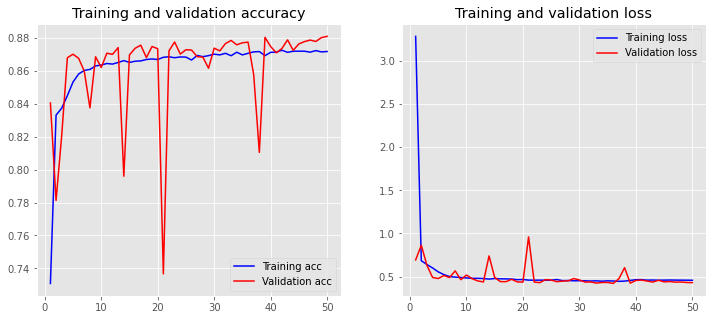

In [395]:
#plot_history(history)

# Exercise 2:

Predict the test data using the trained model. Display 10 original activities from the test dataset and predicted activities.

Expected output:
- Talking-Standing Talking-Standing
- Talking-Standing Talking-Standing
- Talking-Standing Talking-Standing
- Talking-Standing Talking-Standing
- Standing Talking-Standing
- Walking Walking
- Talking-Standing Talking-Standing
- Talking-Standing Talking-Standing
- Standing Talking-Standing
- Talking-Standing Talking-Standing

In [28]:
class_name = ["", "Working at Computer", "Walking up-down", "Standing", "Walking", "Going up-down", "Walking-Talking", "Talking-Standing"]
cpredict = model.predict(X_test)

#Display 10 data of actual and predicted data

for i,y in zip(cpredict[:10], y_test[:10]):    
    invertedy = np.argmax(y)    
    invertedp = np.argmax(i)    
    print(class_name[invertedy], class_name[invertedp])

Talking-Standing Talking-Standing
Working at Computer Working at Computer
Walking Walking
Walking Walking
Talking-Standing Talking-Standing
Walking up-down Talking-Standing
Working at Computer Working at Computer
Talking-Standing Talking-Standing
Walking-Talking Walking
Going up-down Going up-down


# Exercise 3:

Predict the air pressure of weather data in PRSA_data.csv using 1D CNN model. Use a single column data pressure (PRES) for a seven day period as timesteps as feature input, the input shape becomes (7, 1). For the regression model, the target air pressure value of a particular time windows (eg. 7) is decided based on statistical max, mean, or mode value. Develop 1D CNN model to predict the air pressure with the following model configuration.

Model Summary:

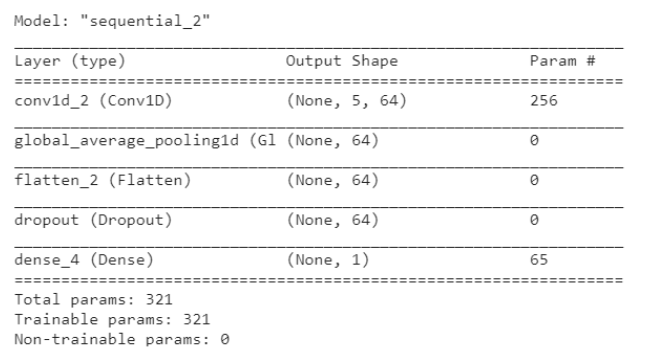

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn import preprocessing
import os
import sys
from tensorflow.keras.callbacks import ModelCheckpoint
from scipy import stats


# Read the data from PRSA_data.csv
# Display its shape and top 5 dataset

In [6]:
#Read the dataset into a pandas.DataFrame

wdata = pd.read_csv("./dataset/PRSA_data.csv")
print(wdata.shape)
print(wdata.head())

(43824, 14)
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir  \
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0   
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0   
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0   
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0   
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0   

              datetime  
0  2010-01-01 00:00:00  
1  2010-01-01 01:00:00  
2  2010-01-01 02:00:00  
3  2010-01-01 03:00:00  
4  2010-01-01 04:00:00  


# Extract feature column PRES and scale using MinMaxScaller
# Append scaled data as scaled_PRES in dataframe

In [8]:
X = wdata['PRES'].to_numpy().reshape(-1, 1)
print(X.shape)
scaler = preprocessing.MinMaxScaler()
x_scaled = scaler.fit_transform(X)
wdata['scaled_PRES'] = x_scaled

(43824, 1)


# Function to generate timesteps, feature format

Use mean data of the timesteps as a targeted label and return as y 

eg. stats.tmax(array_like)

In [10]:
def genTimestepData1(ts, fcol, ntimesteps):    
    X = []
    y = []
    dcol = ts.loc[:, fcol]
    #print(stats.tmean(dcol.loc[50-ntimesteps:50-1]))
    for i in range(ntimesteps, dcol.shape[0]):
        X.append(list(dcol.loc[i-ntimesteps:i-1]))        
        y.append(stats.tmean(dcol.loc[i-ntimesteps:i-1]))
        #y.append(dcol.loc[i])
    X, y = np.array(X), np.array(y)
    return X, y

# Generate feature and target data using 7 days as timesteps for scaled_PRES column of dataset

In [11]:
X_all, y_all = genTimestepData1(wdata, "scaled_PRES", 7)


# Split the data into 80% train and 20% test dataset  

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2)

# Reshape the data into final tensor shape of (samples, timesteps, features)

Expected output:
- (35053, 7, 1)
- (8764, 7, 1)

In [14]:
X_train = X_train.reshape(X_train.shape[0], 7, 1)
X_test = X_test.reshape(X_test.shape[0], 7, 1)

print(X_train.shape)
print(X_test.shape)


(35053, 7, 1)
(8764, 7, 1)


# Create 1D CNN model with the following layer configuration

Model summary:

- Input layer with input shape of (7, 1)
- Add Conv1D layer with 64 filers and a kernel size of 3 with Relu activation and valid padding
- Add Global Max Pooling 1D
- Flatten layer
- Add 20% dropout layer
- Add dense layer single regressed value with linear activation function

In [15]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(7, 1)))
model.add(tf.keras.layers.Conv1D(filters = 64, kernel_size = 3))
model.add(tf.keras.layers.GlobalMaxPool1D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(1, activation='linear'))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 5, 64)             256       
_________________________________________________________________
global_max_pooling1d (Global (None, 64)                0         
_________________________________________________________________
flatten (Flatten)            (None, 64)                0         
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense (Dense)                (None, 1)                 65        
Total params: 321
Trainable params: 321
Non-trainable params: 0
_________________________________________________________________


# Compile the model with mean_absolute_error loss function and adam optimizer

In [17]:
model.compile(optimizer='adam', loss = 'mean_absolute_error')

# Create ModelCheckPoint to save model eg. "AIRPRES_1DConv_weights.14-0.0019" format under models folder

In [18]:
save_weights_at = os.path.join('models', 'AIRPRES_1DConv_weights_{epoch:02d}-{val_loss:.4f}.hdf5')
save_best = ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,  save_best_only=True, 
                          save_weights_only=False)

# Train the model for 20 epoches with validation and callbacks using checkpoint model from previous step

In [19]:
model.fit(X_train, y_train, batch_size=16, epochs=20, verbose=1, callbacks=[save_best], 
validation_data=(X_test, y_test),shuffle=True)

Epoch 1/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0236 - val_loss: 0.0132
Epoch 2/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0126 - val_loss: 0.0053
Epoch 3/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0100 - val_loss: 0.0019
Epoch 4/20
2191/2191 [==============================] - 2s 994us/step - loss: 0.0093 - val_loss: 0.0021
Epoch 5/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0089 - val_loss: 0.0076
Epoch 6/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0090 - val_loss: 0.0049
Epoch 7/20
2191/2191 [==============================] - 2s 958us/step - loss: 0.0090 - val_loss: 0.0050
Epoch 8/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0089 - val_loss: 0.0028
Epoch 9/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0.0089 - val_loss: 0.0027
Epoch 10/20
2191/2191 [==============================] - 2s 1ms/step - loss: 0

# Load the saved model from the previous step
# Predict test data using the model

Note: Trained data was scaled using MaxMinScaler, predicted output eg. preds need to be inversed back with the same scaler object.
eg. scaler.inverse_transform(preds)
 

In [22]:

best_model = tf.keras.models.load_model("./models/AIRPRES_1DConv_weights_01-0.0128.hdf5")

preds = best_model.predict(X_test)

pred_PRES = scaler.inverse_transform(preds)
print(pred_PRES[:10])


[[1015.26324]
 [1012.71545]
 [1009.3155 ]
 [1016.2894 ]
 [1028.6077 ]
 [1002.4942 ]
 [1023.7008 ]
 [1015.4894 ]
 [1002.5415 ]
 [1002.2463 ]]


# Display the R-squared value of the validation dataset

Expected output:

- R-squared for the validation set: 0.9902

In [23]:
from sklearn.metrics import r2_score

org_PRES = scaler.inverse_transform(y_test.reshape(-1, 1))

r2 = r2_score(org_PRES, pred_PRES)

print('R-squared for the validation set:', round(r2, 4))


R-squared for the validation set: 0.9871


# Plot the 50 of the actual and predicted data

Text(0.5, 0, 'Index')

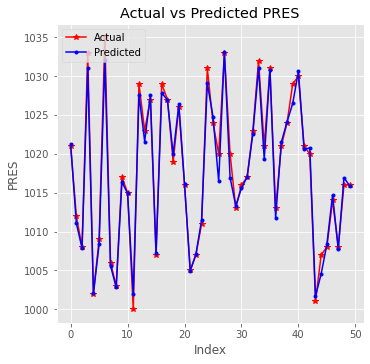

In [377]:
'''
plt.figure(figsize=(5.5, 5.5))
plt.plot(__________, _______________, linestyle='-', marker='*', color='r')

plt.plot(___________, ______________, linestyle='-', marker='.', color='b')

plt.legend(['Actual','Predicted'], loc=2)
plt.title('Actual vs Predicted PRES')
plt.ylabel('PRES')
plt.xlabel('Index')
'''